In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Variance on measurements of noise-diode and other calibrators

Notebook for testing the level of variance when attempting to measure the radiometric temperature of a source such as the noise-diode using the quatient

$$q = \frac{p_{\rm src} - p_{\rm L}}{p_{\rm NS} - p_{\rm L}} \approx \frac{T_{\rm src} - T_{\rm L}}{T_{\rm NS} - T_{\rm L}}$$

where the $\approx$ sign indicates the case of perfectly matched sources

This would be used in the equation

$$T_{\rm src} \approx (T_{\rm NS} - T_{\rm L}) q + T_{\rm L}$$

to calibrate out the $g$ and $T_0$ portions of the radiometer power contributions.

for perfectly matched sources.

In general

$$\left( \frac{\sigma_q}{q} \right)^2 = \frac{1}{\Delta\nu\tau} \left[ \frac{P_{\rm src}^2}{(P_{src} - P_{\rm L})^2} \frac{1}{\phi_{\rm src}} + \frac{P_{\rm NS}^2}{(P_{\rm NS} - P_{\rm L})^2} \frac{1}{\phi_{\rm NS}} + \frac{P_{\rm L}^2 \left(P_{\rm src} - P_{\rm NS}\right)^2}{\left( P_{\rm NS} - P_{\rm L} \right)^2 \left( P_{\rm src} - P_{\rm L} \right)^2 } \frac{1}{\phi_{\rm L}} \right]$$

If $p_{\rm i} = g(T_{\rm i} (1 - |\Gamma_{\rm rec}|^2) + T_0)$

where $i \in \{NS, L, ND\}$ where ND is specifically the noise diode and NS is the heated load


The variance on measurements of $T_{\rm src}$ can be given by

$$ \sigma_{T_{\rm src}}^2  = \frac{(T_{\rm NS} - T_{\rm L})^2}{\delta \nu \tau} \left[ 
    \frac{p_{\rm src}^2}{(p_{\rm NS} - p_{\rm L})^2} \frac{1}{\phi_{\rm src}} +
    \frac{p_{\rm NS}^2 (p_{\rm src} - p_{\rm L})^2}{(p_{\rm NS} - p_{\rm L})^4} \frac{1}{\phi_{\rm NS}} +
    \frac{p_{\rm L}^2 (p_{\rm src} - p_{\rm NS})^2}{(p_{\rm NS} - p_{\rm L})^4} \frac{1}{\phi_{\rm L}}
\right] $$

For now, lets assume that $\phi_i = 1/3$

In [5]:
def dB_to_lin(dB):
    return 10**(dB / 10)

def compute_radiometer_power(T_src,
                             T_unc,
                             T_sin,
                             T_cos,
                             T_0,
                             Gamma_rec,
                             Gamma_src,
                             gain=1000,
                             delta_nu=1e4):
    
    F_src = np.sqrt(1 - (np.abs(Gamma_rec)**2)) / (1 - (Gamma_rec*Gamma_src))

    p_src = gain * delta_nu *  ((T_src * (1 - (np.abs(Gamma_src)**2)) * np.abs(F_src)**2) + \
                    (T_unc * np.abs(Gamma_src)**2 * np.abs(F_src)**2) + \
                    (T_cos * np.real(Gamma_src * F_src)) + \
                    (T_sin * np.imag(Gamma_src * F_src)) + \
                    T_0)

    return p_src
    
def t_src_var(T_ns,
              T_l,
              T_src,
              T_0,
              T_unc,
              T_cos,
              T_sin,
              gamma_rec,
              gamma_src = 0,
              gamma_l = 0,
              gamma_ns = 0,
              g=1000,
              delta_nu = 20e6 / 8192,
              tau = 60,
              phi_src=1/3,
              phi_l=1/3,
              phi_ns=1/3):
    p_src = compute_radiometer_power(T_src, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_src, g, delta_nu)
    p_l = compute_radiometer_power(T_l, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_l, g, delta_nu)
    p_ns = compute_radiometer_power(T_ns, T_unc, T_sin,
                                     T_cos, T_0, gamma_rec,
                                     gamma_ns, g, delta_nu)
    
    multiplier = np.power(T_ns - T_l, 2) / (delta_nu * tau)

    src_term = np.power(p_src, 2) / (np.power(p_ns - p_l, 2)*phi_src)

    ns_term = np.power(p_ns, 2) * np.power(p_src - p_l, 2) / (np.power(p_ns - p_l, 4)*phi_ns)

    l_term = np.power(p_l, 2) * np.power(p_src - p_ns, 2) / (np.power(p_ns - p_l, 4)*phi_l)

    return multiplier * (src_term + ns_term + l_term)

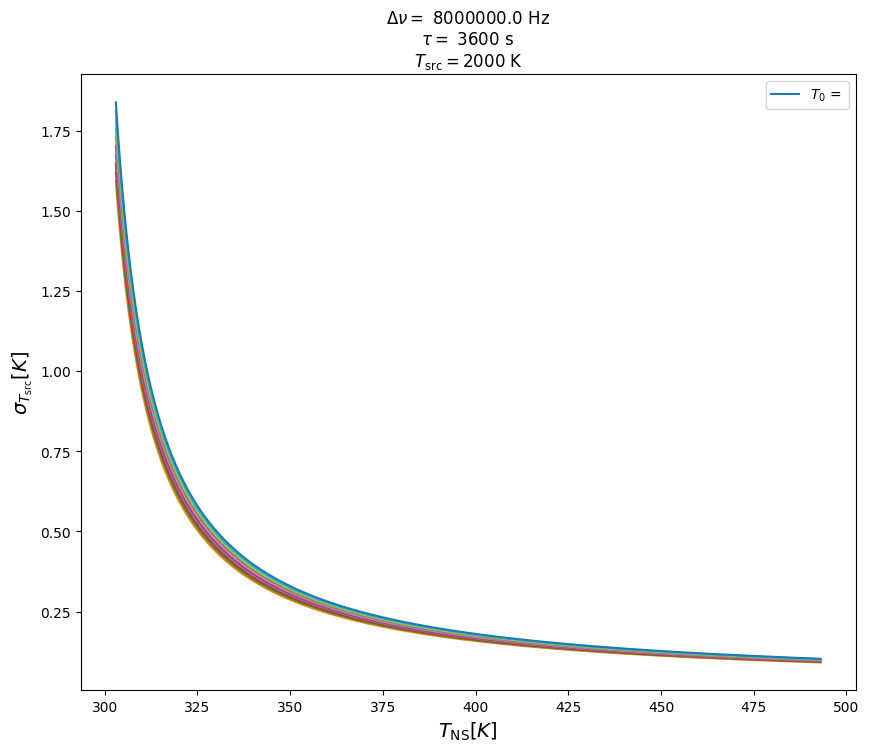

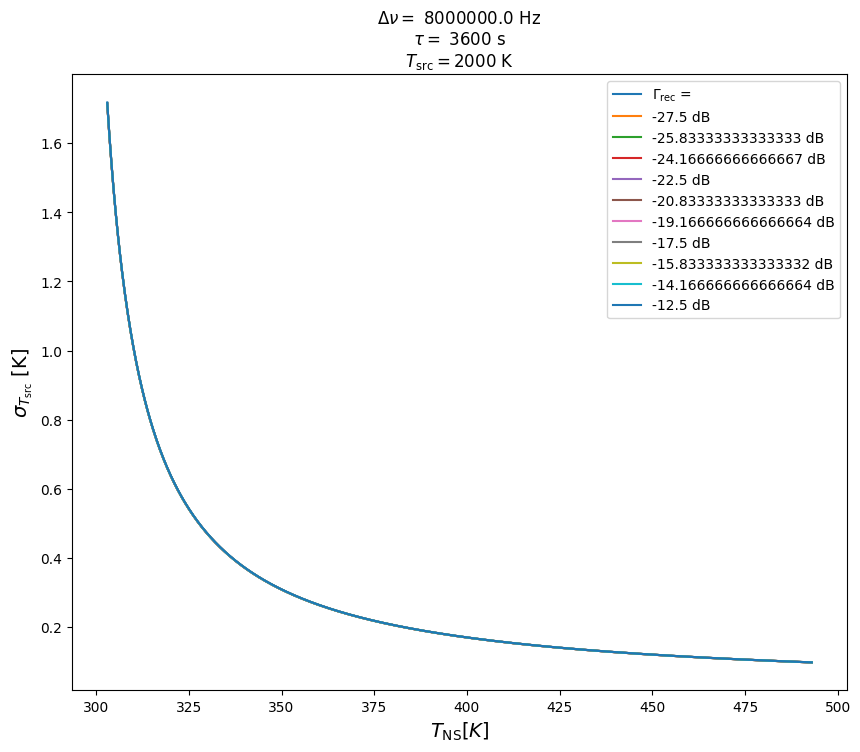

280.0
[0.00039985 0.00039112 0.00038283 0.00037493 0.00036742 0.00036025
 0.00035341 0.00034688 0.00034064 0.00033466 0.00032895 0.00032347
 0.00031822 0.00031318 0.00030834 0.0003037  0.00029923 0.00029493
 0.0002908  0.00028681 0.00028298 0.00027927 0.0002757  0.00027226
 0.00026893 0.00026572 0.00026261 0.0002596  0.0002567  0.00025388
 0.00025116 0.00024852 0.00024596 0.00024348 0.00024107 0.00023873
 0.00023647 0.00023427 0.00023213 0.00023005 0.00022803 0.00022607
 0.00022416 0.0002223  0.00022049 0.00021873 0.00021701 0.00021534
 0.00021371 0.00021213 0.00021058 0.00020907 0.0002076  0.00020616
 0.00020476 0.00020339 0.00020205 0.00020074 0.00019947 0.00019822
 0.000197   0.00019581 0.00019465 0.00019351 0.00019239 0.0001913
 0.00019023 0.00018919 0.00018816 0.00018716 0.00018618 0.00018522
 0.00018428 0.00018335 0.00018245 0.00018156 0.00018069 0.00017984
 0.000179   0.00017818 0.00017738 0.00017659 0.00017581 0.00017505
 0.0001743  0.00017357 0.00017285 0.00017214 0.00017144 0

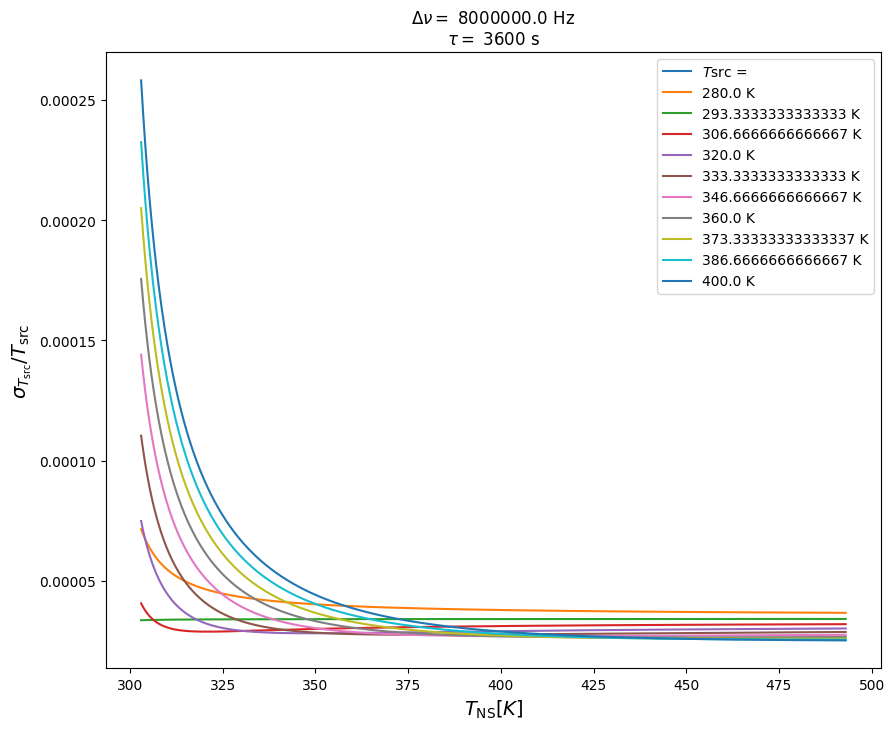

In [46]:
T_0 = 400 # K
GAMMA_REC_DB = -20
GAMMA_REC = dB_to_lin(GAMMA_REC_DB)
T_unc = 300
T_sin = 20
T_cos = 20
DELTA_NU = 8e6
TAU = 3600
g = 1000

T_L = 293
T_src = 2000


t_ns = np.linspace(293+10, 293+200, 1000)


n_steps = 10
T_0_span = 100
gamma_rec_span_db = 15 # pm dB

t_src_array = np.linspace(280, 400, n_steps)

T_0_array = np.linspace(T_0 - (T_0_span/2),
                        T_0 + (T_0_span/2),
                        n_steps)

plt.plot([],[], label=r'$T_0$ = ')
for t_0 in T_0_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=T_src,
                                T_0=t_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=GAMMA_REC,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    
    plt.plot(t_ns, np.sqrt(t_src_var_array))#,
             #label=f"{t_0} K")
plt.ylabel(r'$\sigma_{T_{\rm src}} [K]$', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [K]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s \n'\
            + r'$T_{\rm src} =$' + f'{T_src} K')
plt.legend()
plt.show()


gamma_array_dB = np.linspace(GAMMA_REC_DB - (gamma_rec_span_db/2),
                        GAMMA_REC_DB + (gamma_rec_span_db/2),
                        n_steps)
gamma_lin_array = dB_to_lin(gamma_array_dB)


plt.plot([],[], label=r'$\Gamma_{\rm rec}$ = ')
for gamma_rec in gamma_lin_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=T_src,
                                T_0=T_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=gamma_rec,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    
    plt.plot(t_ns, np.sqrt(t_src_var_array),
             label=f"{10*np.log10(gamma_rec)} dB")
plt.ylabel(r'$\sigma_{T_{\rm src}}$ [K]', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [K]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s \n'\
            + r'$T_{\rm src} =$' + f'{T_src} K')
plt.legend()
plt.show()


plt.plot([],[], label=r'$T{\rm src}$ = ')
for t_src in t_src_array:
    t_src_var_array = t_src_var(T_ns=t_ns,
                                T_l=T_L,
                                T_src=t_src,
                                T_0=T_0,
                                T_unc=T_unc,
                                T_cos=T_cos,
                                T_sin=T_sin,
                                gamma_rec=GAMMA_REC,
                                delta_nu=DELTA_NU,
                                tau=TAU)
    print(t_src)
    print(t_src_var_array)

    plt.plot(t_ns, np.sqrt(t_src_var_array) / t_src,
             label=f"{t_src} K")
plt.ylabel(r'$\sigma_{T_{\rm src}} / T_{\rm src}$', fontsize=14)
plt.xlabel(r'$T_{\rm NS} [K]$', fontsize=14)
plt.gcf().set_size_inches((10.,8))
plt.title(r'$\Delta \nu = $'+f' {DELTA_NU} Hz \n' +\
          r'$\tau = $'+f' {TAU} s'
          )
plt.legend()
plt.show()